
# Oxford-IIIT Pet Breed Classification — CNN Project

**Dataset:** [Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/) (Parkhi et al., CVPR 2012)
**Task:** Classify a photo of a cat or dog into one of **37 breeds** (12 cat breeds, 25 dog breeds).

This notebook follows the full CNN project checklist:
1. Data Loading
2. Data Inspection & EDA
3. Data Preprocessing
4. Data Augmentation
5. Data Splitting
6. CNN Model Development (custom CNN)
7. Transfer Learning / Fine-Tuning (MobileNetV2)
8. Training & Validation
9. Experimentation & Comparison
10. Testing & Evaluation
11. Model Saving
12. Working Prototype (see the separate `pet_breed_app.py` Streamlit app)



In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 0. Setup — Imports & Configuration

In [6]:

import os, io, json, random, time, tarfile, pathlib, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, precision_recall_fscore_support)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR   = pathlib.Path("data")
IMAGES_DIR = DATA_DIR / "images"
ANNOT_DIR  = DATA_DIR / "annotations"

IMG_SIZE   = (160, 160)   # width, height fed to the models
BATCH_SIZE = 32

DATA_DIR.mkdir(exist_ok=True)
print("TensorFlow:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]



## 1. Data Loading




In [7]:


COLAB_SOURCE = None   # None | "drive" | "upload"

if COLAB_SOURCE == "drive":
    from google.colab import drive
    import shutil
    drive.mount("/content/drive")

    # Adjust this if your "dataset" folder lives somewhere else in Drive
    DRIVE_DATASET_DIR = pathlib.Path("/content/drive/MyDrive/dataset")

    for fname in ["images.tar.gz", "annotations.tar.gz"]:
        src, dst = DRIVE_DATASET_DIR / fname, DATA_DIR / fname
        assert src.exists(), f"Could not find {src} -- update DRIVE_DATASET_DIR to match your Drive layout."
        if not dst.exists():
            shutil.copy(src, dst)
            print(f"Copied {fname} from Google Drive.")

elif COLAB_SOURCE == "upload":
    from google.colab import files
    print("Select images.tar.gz and annotations.tar.gz from the dataset folder on your computer:")
    uploaded = files.upload()
    for fname in uploaded:
        pathlib.Path(fname).rename(DATA_DIR / fname)
# ---------------------------------------------------------------------------

for fname in ["images.tar.gz", "annotations.tar.gz"]:
    fpath = DATA_DIR / fname
    assert fpath.exists(), f"Missing {fpath} -- put {fname} in the data/ folder first."

for fname, target in [("images.tar.gz", DATA_DIR), ("annotations.tar.gz", DATA_DIR)]:
    marker = DATA_DIR / f".{fname}.extracted"
    if not marker.exists():
        print(f"Extracting {fname} ...")
        with tarfile.open(DATA_DIR / fname) as tf_:
            tf_.extractall(target)
        marker.touch()
    else:
        print(f"{fname} already extracted, skipping.")

print("images/     :", len(list(IMAGES_DIR.glob('*.jpg'))), "jpg files")
print("annotations/:", os.listdir(ANNOT_DIR))


Extracting images.tar.gz ...
Extracting annotations.tar.gz ...
images/     : 7390 jpg files
annotations/: ['trainval.txt', 'xmls', 'list.txt', 'README', 'trimaps', 'test.txt', '._trimaps']


In [8]:

cols = ["image", "class_id", "species", "breed_id"]
full_list = pd.read_csv(ANNOT_DIR / "list.txt", comment="#", sep=" ", names=cols)

full_list["breed"] = full_list["image"].str.rsplit("_", n=1).str[0]
full_list["species_name"] = full_list["species"].map({1: "Cat", 2: "Dog"})
full_list["filepath"] = full_list["image"].apply(lambda x: str(IMAGES_DIR / f"{x}.jpg"))
full_list["exists"] = full_list["filepath"].apply(os.path.exists)

print("Total labeled images:", len(full_list))
print("Images actually found on disk:", full_list['exists'].sum())
full_list.head()


Total labeled images: 7349
Images actually found on disk: 7349


,image,class_id,species,breed_id,breed,species_name,filepath,exists
0,Abyssinian_100,1,1,1,Abyssinian,Cat,data/images/Abyssinian_100.jpg,True
1,Abyssinian_101,1,1,1,Abyssinian,Cat,data/images/Abyssinian_101.jpg,True
2,Abyssinian_102,1,1,1,Abyssinian,Cat,data/images/Abyssinian_102.jpg,True
3,Abyssinian_103,1,1,1,Abyssinian,Cat,data/images/Abyssinian_103.jpg,True
4,Abyssinian_104,1,1,1,Abyssinian,Cat,data/images/Abyssinian_104.jpg,True


## 2. Data Inspection & EDA

species_name
Dog    4978
Cat    2371
Name: count, dtype: int64 

Number of breeds: 37
count     37.000000
mean     198.621622
std        3.522557
min      184.000000
25%      199.000000
50%      200.000000
75%      200.000000
max      200.000000
Name: count, dtype: float64


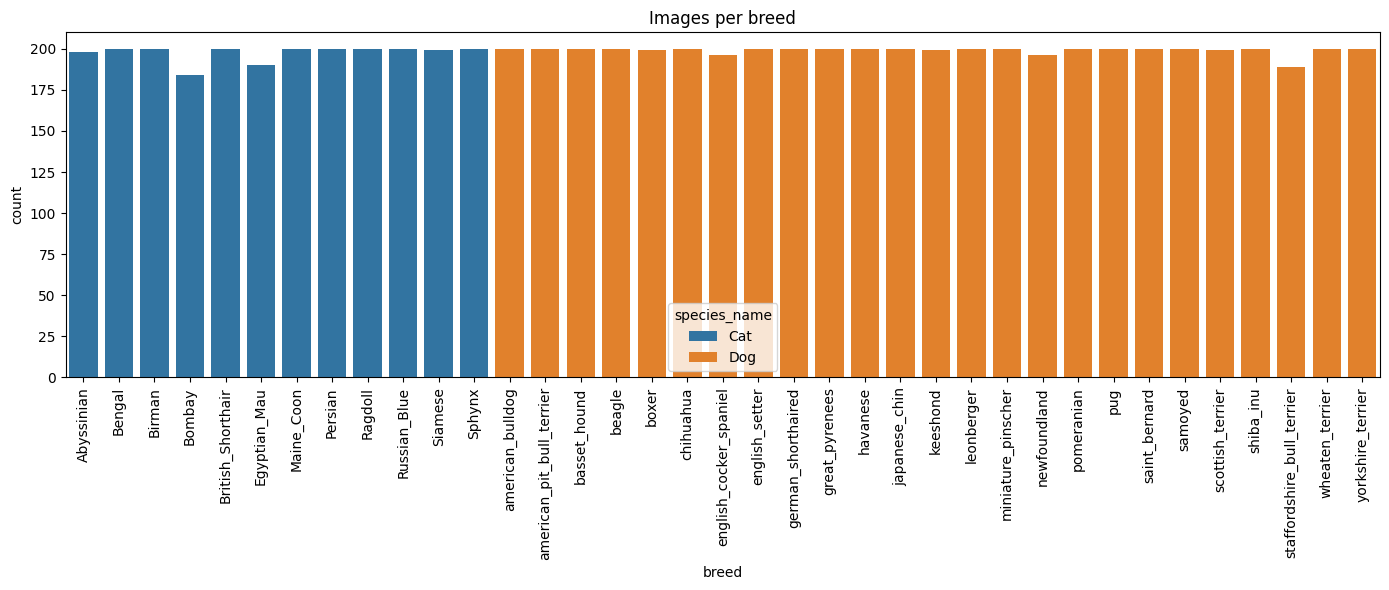

In [9]:

print(full_list["species_name"].value_counts(), "\n")

breed_counts = full_list.groupby(["species_name", "breed"]).size().reset_index(name="count")
print(f"Number of breeds: {breed_counts['breed'].nunique()}")
print(breed_counts["count"].describe())

plt.figure(figsize=(14, 6))
order = breed_counts.sort_values(["species_name", "breed"])["breed"]
sns.barplot(data=breed_counts, x="breed", y="count", hue="species_name", dodge=False)
plt.xticks(rotation=90)
plt.title("Images per breed")
plt.tight_layout()
plt.show()


             width      height  aspect_ratio
count   500.000000  500.000000    500.000000
mean    434.590000  401.732000      1.136992
std      95.684654   87.317013      0.338198
min     174.000000  135.000000      0.517598
25%     348.000000  333.000000      0.750000
50%     500.000000  375.000000      1.333333
75%     500.000000  500.000000      1.481491
max    1280.000000  800.000000      1.893939

Color modes found:
 mode
RGB    500
Name: count, dtype: int64


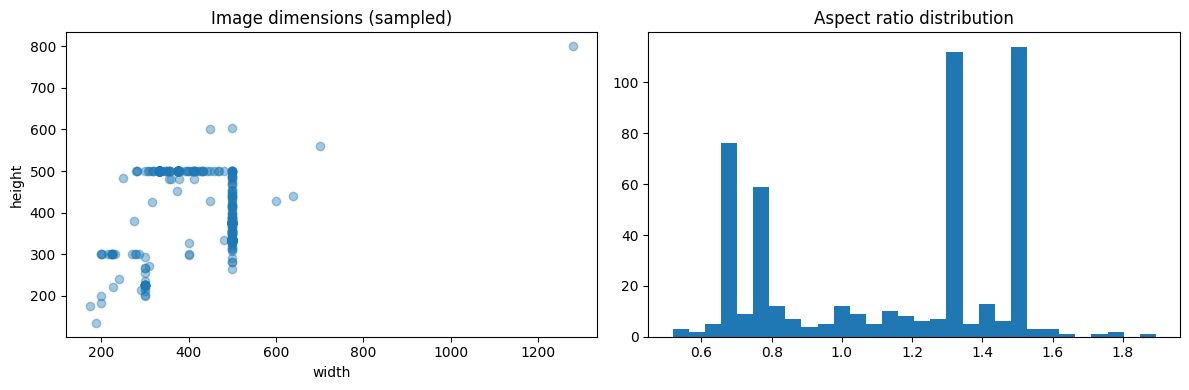

In [10]:

sample_paths = full_list[full_list["exists"]].sample(min(500, full_list["exists"].sum()), random_state=SEED)
dims = []
for p in sample_paths["filepath"]:
    with Image.open(p) as im:
        dims.append((im.width, im.height, im.mode))
dim_df = pd.DataFrame(dims, columns=["width", "height", "mode"])
dim_df["aspect_ratio"] = dim_df["width"] / dim_df["height"]

print(dim_df[["width", "height", "aspect_ratio"]].describe())
print("\nColor modes found:\n", dim_df["mode"].value_counts())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(dim_df["width"], dim_df["height"], alpha=0.4)
ax[0].set_xlabel("width"); ax[0].set_ylabel("height"); ax[0].set_title("Image dimensions (sampled)")
ax[1].hist(dim_df["aspect_ratio"], bins=30)
ax[1].set_title("Aspect ratio distribution")
plt.tight_layout()
plt.show()


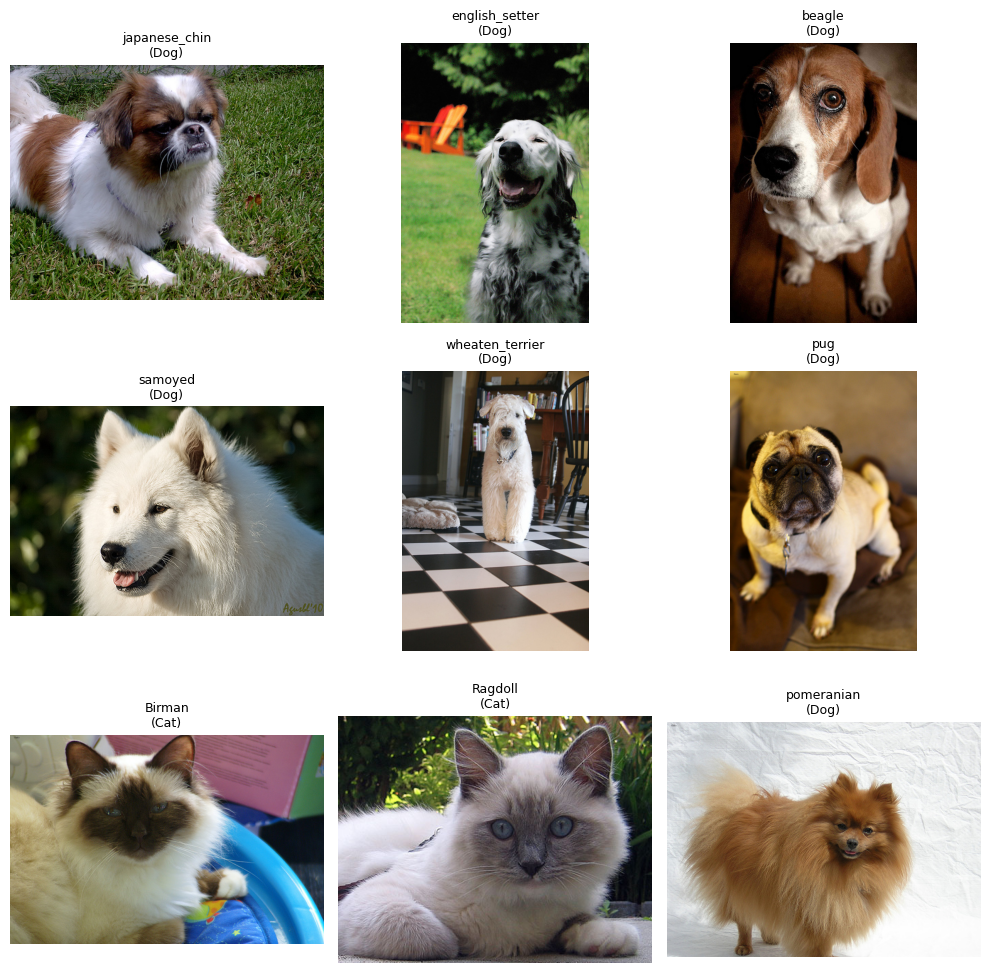

In [11]:


sample_breeds = full_list["breed"].drop_duplicates().sample(9, random_state=SEED)
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, breed in zip(axes.flat, sample_breeds):
    row = full_list[(full_list["breed"] == breed) & (full_list["exists"])].iloc[0]
    img = Image.open(row["filepath"])
    ax.imshow(img)
    ax.set_title(f"{breed}\n({row['species_name']})", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [12]:

# --- Data-quality checks: unreadable / non-RGB / missing files -------------
bad_files, non_rgb = [], []
for p in full_list.loc[full_list["exists"], "filepath"]:
    try:
        with Image.open(p) as im:
            if im.mode != "RGB":
                non_rgb.append(p)
    except Exception as e:
        bad_files.append((p, str(e)))

print(f"Unreadable / corrupted files: {len(bad_files)}")
for p, e in bad_files[:10]:
    print(" -", p, "->", e)

print(f"\nNon-RGB files (grayscale / CMYK / palette, need conversion): {len(non_rgb)} sampled-checked "
      f"out of {full_list['exists'].sum()} (full scan run below)")


Unreadable / corrupted files: 0

Non-RGB files (grayscale / CMYK / palette, need conversion): 3 sampled-checked out of 7349 (full scan run below)


In [13]:

# Fulldataset scan for corrupted files and duplicate filenames
missing = full_list[~full_list["exists"]]
dupes = full_list[full_list.duplicated("image", keep=False)]
print("Missing image files listed in annotations but not found on disk:", len(missing))
print("Duplicate 'image' entries in list.txt:", len(dupes))


Missing image files listed in annotations but not found on disk: 0
Duplicate 'image' entries in list.txt: 0



## 3. Data Preprocessing (Cleaning + Resize/Normalize)


In [14]:

clean_df = full_list[full_list["exists"]].copy()
bad_set = {p for p, _ in bad_files}
clean_df = clean_df[~clean_df["filepath"].isin(bad_set)].reset_index(drop=True)

# Encode breed labels 0..36
breed_classes = sorted(clean_df["breed"].unique())
breed_to_idx = {b: i for i, b in enumerate(breed_classes)}
idx_to_breed = {i: b for b, i in breed_to_idx.items()}
clean_df["label"] = clean_df["breed"].map(breed_to_idx)

NUM_CLASSES = len(breed_classes)
print(f"Clean dataset: {len(clean_df)} images across {NUM_CLASSES} breeds")

def load_and_resize(path, size=IMG_SIZE):
    img = Image.open(path).convert("RGB").resize(size)
    return np.asarray(img, dtype=np.uint8)


Clean dataset: 7349 images across 37 breeds



## 4. Data Augmentation




In [15]:

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),        # ~±18 degrees
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.1),
], name="data_augmentation")



## 5. Data Splitting



In [16]:

trainval_names = set(pd.read_csv(ANNOT_DIR / "trainval.txt", sep=" ", names=cols)["image"])
test_names     = set(pd.read_csv(ANNOT_DIR / "test.txt", sep=" ", names=cols)["image"])

trainval_df = clean_df[clean_df["image"].isin(trainval_names)].reset_index(drop=True)
test_df     = clean_df[clean_df["image"].isin(test_names)].reset_index(drop=True)

train_df, val_df = train_test_split(
    trainval_df, test_size=0.15, stratify=trainval_df["label"], random_state=SEED
)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
assert set(train_df["image"]).isdisjoint(val_df["image"])
assert set(train_df["image"]).isdisjoint(test_df["image"])
assert set(val_df["image"]).isdisjoint(test_df["image"])
print("No overlap between splits confirmed.")


Train: 3128  Val: 552  Test: 3669
No overlap between splits confirmed.


In [17]:

def make_dataset(df, training, preprocess_fn=None, batch_size=BATCH_SIZE):
    paths  = df["filepath"].values
    labels = df["label"].values

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED)
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)

    if preprocess_fn is not None:
        ds = ds.map(lambda x, y: (preprocess_fn(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(lambda x, y: (x / 255.0, y), num_parallel_calls=tf.data.AUTOTUNE)

    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

# Datasets for the custom CNN (simple [0,1] scaling)
train_ds_cnn = make_dataset(train_df, training=True)
val_ds_cnn   = make_dataset(val_df,   training=False)
test_ds_cnn  = make_dataset(test_df,  training=False)

# Datasets for MobileNetV2 (its own preprocess_input, scales to [-1,1])
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mnv2_preprocess
train_ds_tl = make_dataset(train_df, training=True,  preprocess_fn=mnv2_preprocess)
val_ds_tl   = make_dataset(val_df,   training=False, preprocess_fn=mnv2_preprocess)
test_ds_tl  = make_dataset(test_df,  training=False, preprocess_fn=mnv2_preprocess)



## 6. CNN Model Development (Custom CNN, baseline)

A small custom CNN trained from scratch, used as a **baseline** to compare against transfer learning.



In [18]:

def build_custom_cnn(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for filters in [32, 64, 128]:
        x = layers.Conv2D(filters, 3, padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="custom_cnn")

custom_cnn = build_custom_cnn()
custom_cnn.summary()


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 37)             │         4,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,917 (386.39 KB)

 Trainable params: 98,469 (384.64 KB)

 Non-trainable params: 448 (1.75 KB)

In [19]:

custom_cnn.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_cnn = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy"),
    keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, monitor="val_loss"),
]

EPOCHS_CNN = 20
history_cnn = custom_cnn.fit(
    train_ds_cnn, validation_data=val_ds_cnn,
    epochs=EPOCHS_CNN, callbacks=callbacks_cnn,
)


Epoch 1/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 294ms/step - accuracy: 0.0380 - loss: 3.7643 - val_accuracy: 0.0308 - val_loss: 3.6523 - learning_rate: 0.0010
Epoch 2/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 34s 289ms/step - accuracy: 0.0464 - loss: 3.6380 - val_accuracy: 0.0254 - val_loss: 3.7354 - learning_rate: 0.0010
Epoch 3/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 44s 262ms/step - accuracy: 0.0534 - loss: 3.5784 - val_accuracy: 0.0362 - val_loss: 3.6954 - learning_rate: 0.0010
Epoch 4/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 34s 249ms/step - accuracy: 0.0719 - loss: 3.5019 - val_accuracy: 0.0543 - val_loss: 3.5487 - learning_rate: 5.0000e-04
Epoch 5/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 28s 234ms/step - accuracy: 0.0751 - loss: 3.4699 - val_accuracy: 0.0652 - val_loss: 3.4623 - learning_rate: 5.0000e-04
Epoch 6/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 29s 239ms/step - accuracy: 0.0716 - loss: 3.4445 - val_accuracy: 0.0543 - val_loss: 3.4214 - learning_rate: 5.0000e-04
Epoch 7/20
98/98 ━━━━━━━━━━━━━━━━━━━━ 28s 233ms/step - accuracy: 0.081


## 7. Transfer Learning & Fine-Tuning (MobileNetV2)

**Phase 1 — feature extraction:**


**Phase 2 — fine-tuning:**


In [20]:

base_model = keras.applications.MobileNetV2(
    input_shape=(*IMG_SIZE, 3), include_top=False, weights="imagenet"
)
base_model.trainable = False  # Phase 1: freeze

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
tl_model = keras.Model(inputs, outputs, name="mobilenetv2_transfer")

tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
tl_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 37)             │        47,397 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305,381 (8.79 MB)

 Trainable params: 47,397 (185.14 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [21]:

callbacks_tl = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy"),
]

EPOCHS_FEATURE_EXTRACT = 10
history_tl_phase1 = tl_model.fit(
    train_ds_tl, validation_data=val_ds_tl,
    epochs=EPOCHS_FEATURE_EXTRACT, callbacks=callbacks_tl,
)


Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 74s 497ms/step - accuracy: 0.5285 - loss: 1.7762 - val_accuracy: 0.8261 - val_loss: 0.6391
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 26s 201ms/step - accuracy: 0.8194 - loss: 0.6270 - val_accuracy: 0.8460 - val_loss: 0.4741
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 204ms/step - accuracy: 0.8651 - loss: 0.4563 - val_accuracy: 0.8678 - val_loss: 0.4155
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 41s 203ms/step - accuracy: 0.8907 - loss: 0.3531 - val_accuracy: 0.8841 - val_loss: 0.3893
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 201ms/step - accuracy: 0.8993 - loss: 0.3115 - val_accuracy: 0.8822 - val_loss: 0.3807
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 213ms/step - accuracy: 0.9143 - loss: 0.2686 - val_accuracy: 0.9004 - val_loss: 0.3747
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 220ms/step - accuracy: 0.9271 - loss: 0.2320 - val_accuracy: 0.8913 - val_loss: 0.3675
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 41s 219ms/step - accuracy: 0.9306 - loss: 0.2262 - val_accu

In [22]:


base_model.trainable = True
FINE_TUNE_AT = len(base_model.layers) - 30   # unfreeze roughly the last 30 layers
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-5),   # much smaller LR for fine-tuning
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

EPOCHS_FINE_TUNE = 10
history_tl_phase2 = tl_model.fit(
    train_ds_tl, validation_data=val_ds_tl,
    epochs=EPOCHS_FINE_TUNE, callbacks=callbacks_tl,
)


Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 63s 413ms/step - accuracy: 0.8299 - loss: 0.5201 - val_accuracy: 0.9022 - val_loss: 0.3489
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 28s 209ms/step - accuracy: 0.8705 - loss: 0.4435 - val_accuracy: 0.8986 - val_loss: 0.3431
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 28s 209ms/step - accuracy: 0.8734 - loss: 0.3943 - val_accuracy: 0.8931 - val_loss: 0.3437
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 212ms/step - accuracy: 0.8884 - loss: 0.3577 - val_accuracy: 0.8913 - val_loss: 0.3437
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 217ms/step - accuracy: 0.9003 - loss: 0.3392 - val_accuracy: 0.8931 - val_loss: 0.3419
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 41s 214ms/step - accuracy: 0.9031 - loss: 0.3145 - val_accuracy: 0.8931 - val_loss: 0.3433


## 8. Training & Validation Curves

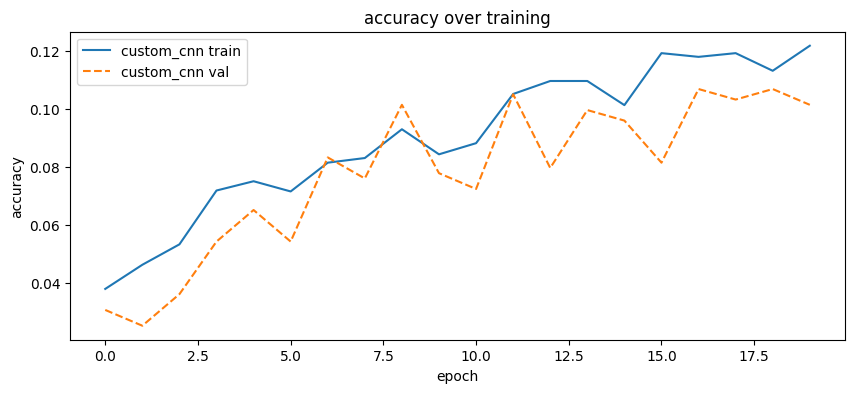

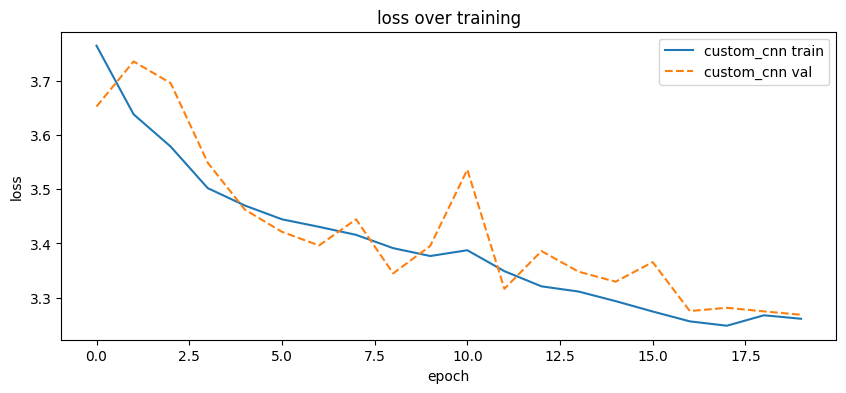

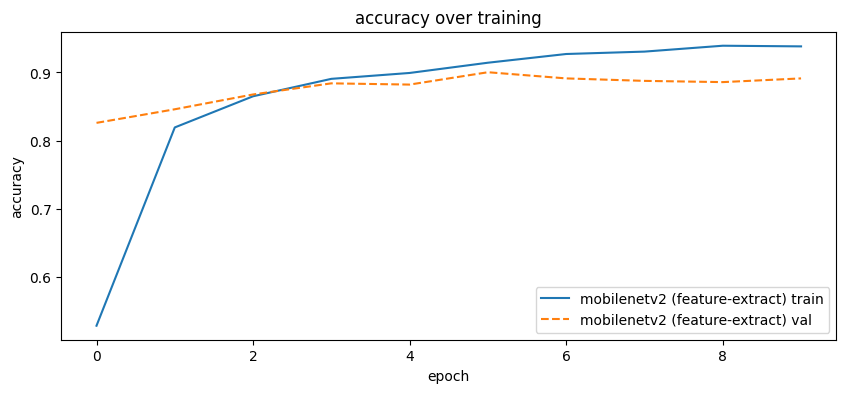

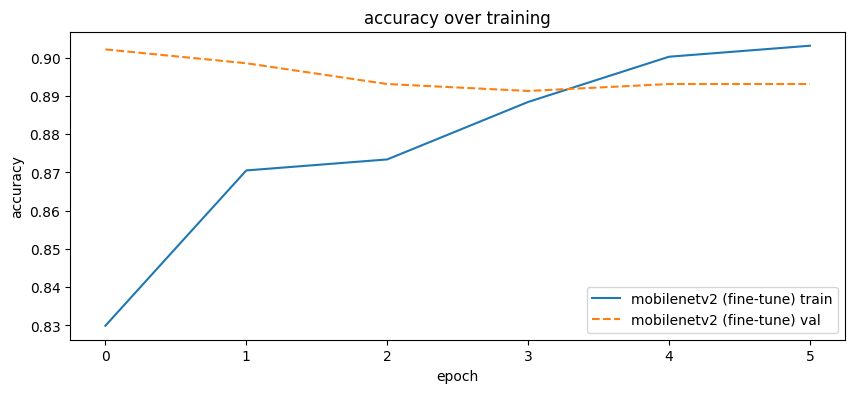

In [23]:

def plot_history(histories, labels, metric="accuracy"):
    plt.figure(figsize=(10, 4))
    for h, lab in zip(histories, labels):
        plt.plot(h.history[metric], label=f"{lab} train")
        plt.plot(h.history[f"val_{metric}"], "--", label=f"{lab} val")
    plt.xlabel("epoch"); plt.ylabel(metric); plt.legend(); plt.title(f"{metric} over training")
    plt.show()

plot_history([history_cnn], ["custom_cnn"], "accuracy")
plot_history([history_cnn], ["custom_cnn"], "loss")
plot_history([history_tl_phase1], ["mobilenetv2 (feature-extract)"], "accuracy")
plot_history([history_tl_phase2], ["mobilenetv2 (fine-tune)"], "accuracy")



## 9. Experimentation & Comparison



                             run  val_accuracy  epochs  seconds
0          custom_cnn (baseline)      0.106884      20      NaN
1  mobilenetv2 (feature-extract)      0.900362      10      NaN
2       mobilenetv2 (fine-tuned)      0.902174       6      NaN
3     custom_cnn (SGD optimizer)      0.063406       8    297.9
4          custom_cnn (lower LR)      0.103261       8    296.9


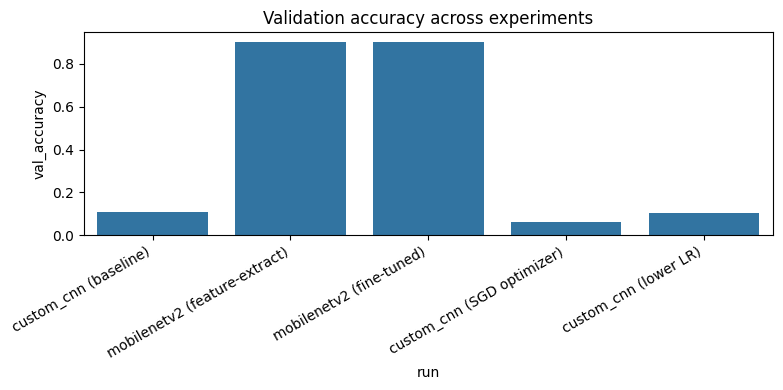

In [24]:

def quick_train_eval(model_fn, train_ds, val_ds, epochs, optimizer, run_name):
    model = model_fn()
    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    t0 = time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=0)
    elapsed = time.time() - t0
    val_acc = max(hist.history["val_accuracy"])
    return {"run": run_name, "val_accuracy": val_acc, "epochs": epochs, "seconds": round(elapsed, 1)}

results = []

results.append({"run": "custom_cnn (baseline)", "val_accuracy": max(history_cnn.history["val_accuracy"]),
                 "epochs": len(history_cnn.history["val_accuracy"]), "seconds": None})


results.append({"run": "mobilenetv2 (feature-extract)", "val_accuracy": max(history_tl_phase1.history["val_accuracy"]),
                 "epochs": len(history_tl_phase1.history["val_accuracy"]), "seconds": None})
results.append({"run": "mobilenetv2 (fine-tuned)", "val_accuracy": max(history_tl_phase2.history["val_accuracy"]),
                 "epochs": len(history_tl_phase2.history["val_accuracy"]), "seconds": None})


results.append(quick_train_eval(
    build_custom_cnn, train_ds_cnn, val_ds_cnn, epochs=8,
    optimizer=keras.optimizers.SGD(learning_rate=1e-2, momentum=0.9),
    run_name="custom_cnn (SGD optimizer)",
))


results.append(quick_train_eval(
    build_custom_cnn, train_ds_cnn, val_ds_cnn, epochs=8,
    optimizer=keras.optimizers.Adam(1e-4),
    run_name="custom_cnn (lower LR)",
))

results_df = pd.DataFrame(results)
print(results_df)

plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="run", y="val_accuracy")
plt.xticks(rotation=30, ha="right")
plt.title("Validation accuracy across experiments")
plt.tight_layout()
plt.show()


## 10. Testing & Evaluation (held-out test set)

In [25]:

# Pick the best-performing model
final_model = tl_model
final_test_ds = test_ds_tl

test_loss, test_acc = final_model.evaluate(final_test_ds)
print(f"Test accuracy: {test_acc:.4f}   Test loss: {test_loss:.4f}")

y_true = test_df["label"].values
y_pred_probs = final_model.predict(final_test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")
print(f"Macro Precision: {precision:.4f}  Recall: {recall:.4f}  F1: {f1:.4f}")

print("\nPer-class report:\n")
print(classification_report(y_true, y_pred, target_names=breed_classes))


115/115 ━━━━━━━━━━━━━━━━━━━━ 21s 182ms/step - accuracy: 0.8659 - loss: 0.4201
Test accuracy: 0.8659   Test loss: 0.4201
115/115 ━━━━━━━━━━━━━━━━━━━━ 18s 116ms/step
Macro Precision: 0.8752  Recall: 0.8658  F1: 0.8650

Per-class report:

                            precision    recall  f1-score   support

                Abyssinian       0.82      0.82      0.82        98
                    Bengal       0.84      0.75      0.79       100
                    Birman       0.73      0.74      0.74       100
                    Bombay       0.95      0.88      0.91        88
         British_Shorthair       0.76      0.84      0.80       100
              Egyptian_Mau       0.86      0.84      0.85        97
                Maine_Coon       0.86      0.71      0.78       100
                   Persian       0.81      0.89      0.85       100
                   Ragdoll       0.60      0.78      0.68       100
              Russian_Blue       0.85      0.77      0.81       100
               

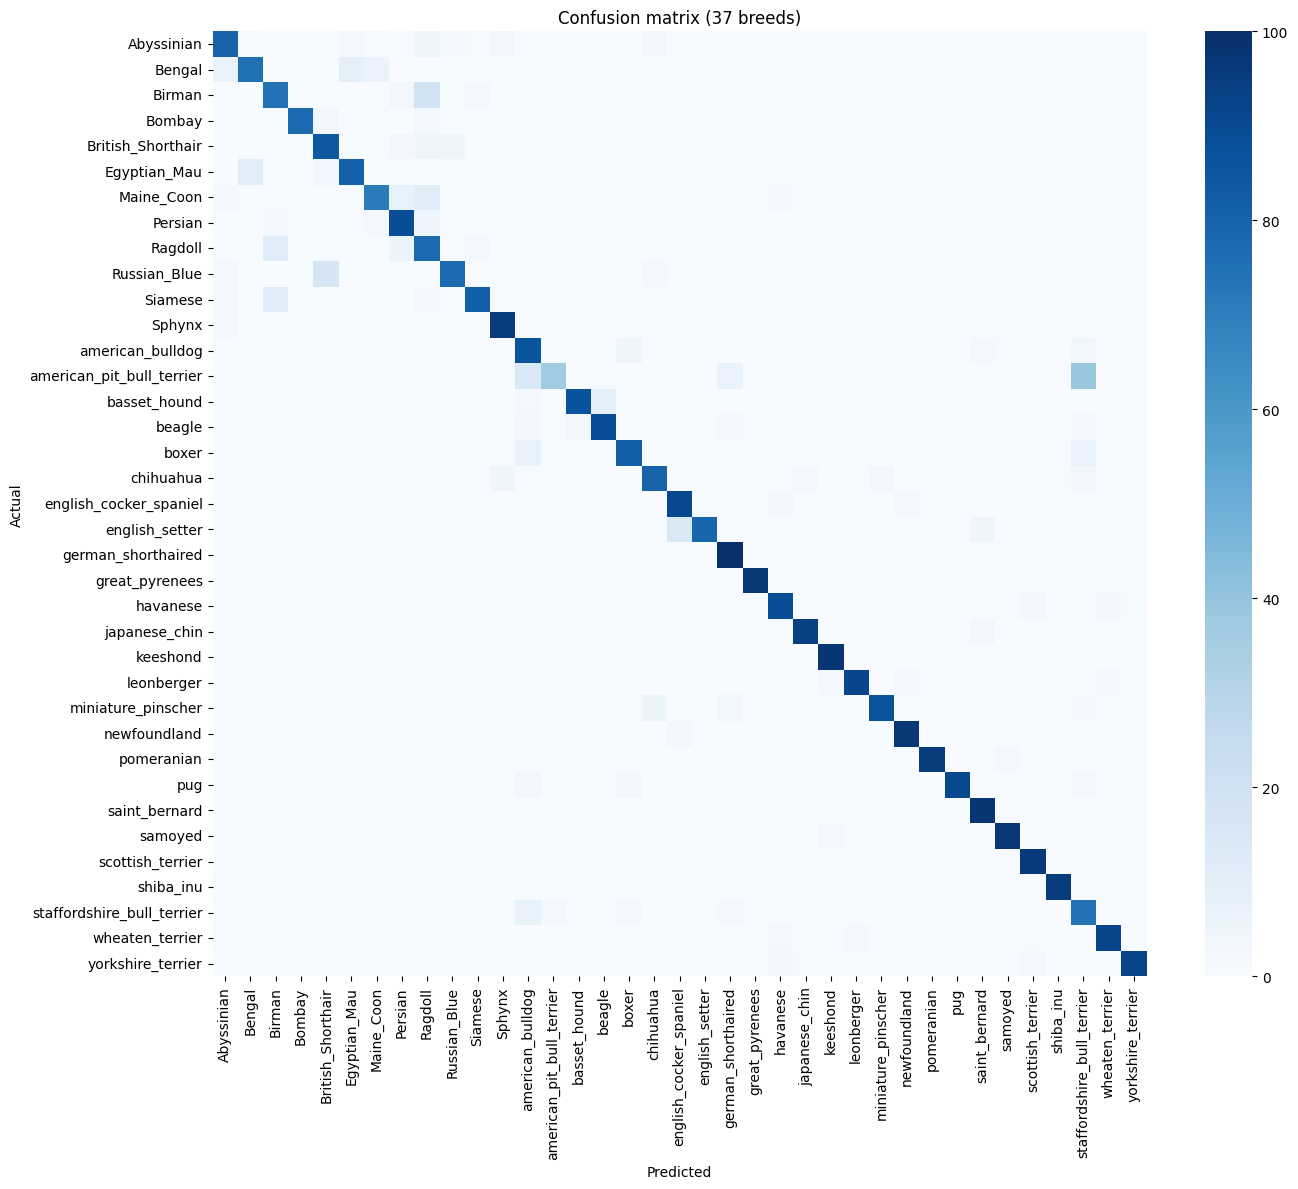

In [26]:

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, xticklabels=breed_classes, yticklabels=breed_classes, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion matrix (37 breeds)")
plt.xticks(rotation=90); plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



## 11. Model Saving



In [27]:

os.makedirs("saved_model", exist_ok=True)
final_model.save("saved_model/pet_breed_mobilenetv2.keras")

with open("saved_model/preprocessing_config.json", "w") as f:
    json.dump({
        "img_size": IMG_SIZE,
        "preprocess": "mobilenet_v2",
        "idx_to_breed": idx_to_breed,
    }, f, indent=2)

print("Saved model + preprocessing config to ./saved_model/")


Saved model + preprocessing config to ./saved_model/


In [29]:
from google.colab import drive
drive.mount('/content/drive')
import shutil
shutil.copytree("saved_model", "/content/drive/MyDrive/saved_model", dirs_exist_ok=True)
print("Backed up to Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Backed up to Drive.


In [30]:
 import shutil
 shutil.copytree("saved_model", "/content/drive/MyDrive/saved_model", dirs_exist_ok=True)
 print("Backed up to Drive.")

Backed up to Drive.
